In [1]:
import pandas as pd

In [14]:
df = pd.read_csv('../SraRunTable.csv', usecols=['Run', 'Bases', 'Bytes'])
df['Coverage'] = df['Bases'] / 133_917_231  # Number of Bases in ColPEK Assembly
df['Bytes / Base'] = df['Bytes'] / df['Bases']
df

,Run,Bases,Bytes,Coverage,Bytes / Base
0,SRR6862404,3961439247,1293517909,29.581251,0.326527
1,SRR6862405,1421272374,558725270,10.613066,0.393116
2,SRR6862406,2795990745,895548902,20.878499,0.320298
3,SRR6862407,4622783460,1432583424,34.519706,0.309896
4,SRR6862408,3599274656,1133648998,26.876860,0.314966
...,...,...,...,...,...
209,SRR6750193,2922793146,1449894043,21.825370,0.496065
210,SRR6750194,6752190804,2976980786,50.420627,0.440891
211,SRR6750199,2640499552,1340584186,19.717400,0.507701
212,SRR6750200,1904903656,963701635,14.224485,0.505906


In [50]:
coverages = df.set_index('Run')['Coverage'].to_dict()
coverages

{'SRR6862404': 29.581251175959576,
 'SRR6862405': 10.613065722662679,
 'SRR6862406': 20.878498787060494,
 'SRR6862407': 34.519706131020584,
 'SRR6862408': 26.876859901620875,
 'SRR6862409': 23.037642728738916,
 'SRR6862410': 32.105145685098584,
 'SRR6862411': 23.105545648565567,
 'SRR6862412': 37.94175349996596,
 'SRR6862413': 22.110373959270408,
 'SRR6862414': 31.421685167609237,
 'SRR6862415': 20.18164057618545,
 'SRR6862416': 14.791388383769673,
 'SRR6862417': 29.317313684599707,
 'SRR6862418': 22.79068519569375,
 'SRR6862419': 26.50588744625402,
 'SRR6862420': 35.43816864015057,
 'SRR6862421': 28.71429345040744,
 'SRR6862422': 24.807862298168338,
 'SRR6862423': 23.264902878704234,
 'SRR6862424': 62.58388784188646,
 'SRR6862425': 45.54958215944593,
 'SRR6862426': 59.72410271834249,
 'SRR6862427': 51.70980932991364,
 'SRR6862428': 39.760550701649436,
 'SRR6862429': 41.06644243562653,
 'SRR6862430': 43.335903674710835,
 'SRR6862431': 63.253708240129306,
 'SRR6862432': 36.9415179290856

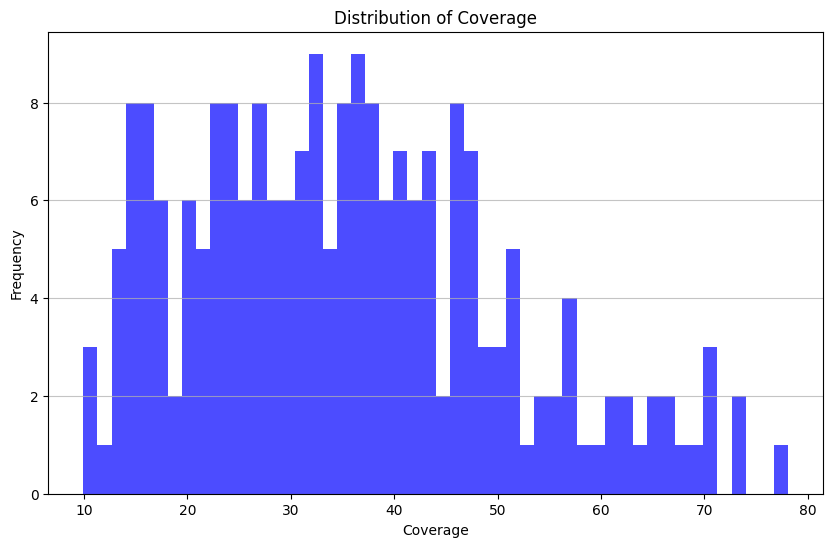

In [9]:
# Plot distribution of coverage
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['Coverage'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Coverage')
plt.xlabel('Coverage')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
sample_count_df = pd.read_csv('../tsvs/SRR6862404.tsv', sep=" ", header=None, names=['Kmer', 'Count'])
sample_count_df.shape

In [43]:
sample_count_df.head(20)

,Kmer,Count
0,AAAAAAAAAAAAAAAAAAAAAAA,1366999
1,ATTTACATGCTCATGGTTTGAAA,10
2,AAGAGACATAAAAACATACATTC,4
3,AATTTATTCCATGGTCAACAATG,13
4,ATTTCACTCCCACAACTAAAAAT,9
5,TTCTATAGAGTAGAGGTCAAAAA,12
6,ATCGCCGACCTTATTGACACGTG,8
7,GTGTAGTGAACTGTCGCCCAGAA,8
8,AGAACTGCTCAACGTTATGGTGG,5
9,GAATCTCTTGCTCGTTGTTACTC,15


In [45]:
# get min, max, mean, median, 25th percentile, 75th percentile
sample_count_df['Count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    1.199846e+08
mean     2.360745e+01
std      4.314652e+02
min      4.000000e+00
25%      1.000000e+01
50%      1.300000e+01
75%      1.600000e+01
90%      1.900000e+01
95%      2.300000e+01
99%      6.600000e+01
max      1.366999e+06
Name: Count, dtype: float64

In [46]:
filtered_count_df = sample_count_df[sample_count_df['Count'] >= 30]
filtered_count_df.shape

(3422585, 2)

In [47]:
filtered_count_df['Count'].describe(percentiles=[0.25, 0.5, 0.75])

count    3.422585e+06
mean     3.950036e+02
std      2.526578e+03
min      3.000000e+01
25%      3.500000e+01
50%      4.800000e+01
75%      1.010000e+02
max      1.366999e+06
Name: Count, dtype: float64